<a href="https://colab.research.google.com/github/valluripavanayyappa-code/CODSOFT_TASK-1/blob/main/MOVIE_GENRE_CLASSIFICATION.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

uploaded = files.upload()

Saving archive (3).zip to archive (3) (1).zip


In [18]:
import zipfile

zip_path = "/content/archive (3).zip"
extract_path = "/content/movie_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Extraction completed.")

Extraction completed.


In [19]:
import os

for root, dirs, files in os.walk("/content/movie_dataset"):
    for file in files:
        print(os.path.join(root, file))

/content/movie_dataset/Genre Classification Dataset/train_data.txt
/content/movie_dataset/Genre Classification Dataset/description.txt
/content/movie_dataset/Genre Classification Dataset/test_data_solution.txt
/content/movie_dataset/Genre Classification Dataset/test_data.txt


In [20]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings("ignore")

In [21]:
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.metrics import accuracy_score
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

from sklearn.model_selection import train_test_split

In [22]:
train_path="/content/movie_dataset/Genre Classification Dataset/train_data.txt"

test_path="/content/movie_dataset/Genre Classification Dataset/test_data.txt"

solution_path="/content/movie_dataset/Genre Classification Dataset/test_data_solution.txt"

In [23]:
train_df=pd.read_csv(
    train_path,
    sep=" ::: ",
    engine="python",
    names=["ID","Title","Genre","Plot"]
)

train_df.head()

,ID,Title,Genre,Plot
0,1,Oscar et la dame rose (2009),drama,Listening in to a conversation between his doc...
1,2,Cupid (1997),thriller,A brother and sister with a past incestuous re...
2,3,"Young, Wild and Wonderful (1980)",adult,As the bus empties the students for their fiel...
3,4,The Secret Sin (1915),drama,To help their unemployed father make ends meet...
4,5,The Unrecovered (2007),drama,The film's title refers not only to the un-rec...


In [24]:
test_df=pd.read_csv(
    test_path,
    sep=" ::: ",
    engine="python",
    names=["ID","Title","Plot"]
)

test_df.head()

,ID,Title,Plot
0,1,Edgar's Lunch (1998),"L.R. Brane loves his life - his car, his apart..."
1,2,La guerra de papá (1977),"Spain, March 1964: Quico is a very naughty chi..."
2,3,Off the Beaten Track (2010),One year in the life of Albin and his family o...
3,4,Meu Amigo Hindu (2015),"His father has died, he hasn't spoken with his..."
4,5,Er nu zhai (1955),Before he was known internationally as a marti...


In [25]:
solution_df=pd.read_csv(
    solution_path,
    sep=" ::: ",
    engine="python",
    names=["ID","Title","Genre","Plot"]
)

solution_df.head()

,ID,Title,Genre,Plot
0,1,Edgar's Lunch (1998),thriller,"L.R. Brane loves his life - his car, his apart..."
1,2,La guerra de papá (1977),comedy,"Spain, March 1964: Quico is a very naughty chi..."
2,3,Off the Beaten Track (2010),documentary,One year in the life of Albin and his family o...
3,4,Meu Amigo Hindu (2015),drama,"His father has died, he hasn't spoken with his..."
4,5,Er nu zhai (1955),drama,Before he was known internationally as a marti...


In [26]:
print("Training Shape :",train_df.shape)
print("Testing Shape :",test_df.shape)

Training Shape : (54214, 4)
Testing Shape : (54200, 3)


In [27]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 54214 entries, 0 to 54213
Data columns (total 4 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   ID      54214 non-null  int64 
 1   Title   54214 non-null  object
 2   Genre   54214 non-null  object
 3   Plot    54214 non-null  object
dtypes: int64(1), object(3)
memory usage: 1.7+ MB


In [28]:
train_df.isnull().sum()

,0
ID,0
Title,0
Genre,0
Plot,0


In [29]:
train_df['Genre'].value_counts()

,count
Genre,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


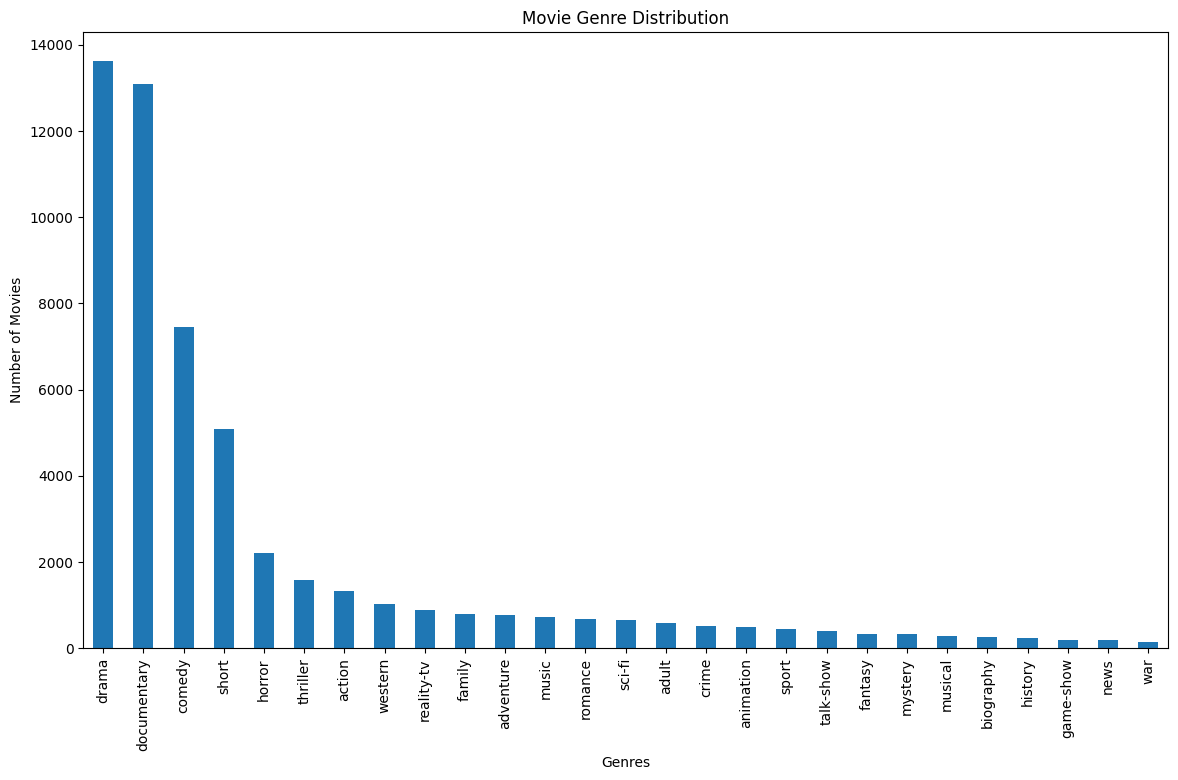

In [30]:
import matplotlib as mpl

plt.figure(figsize=(14,8))

mpl.rcParams['text.usetex'] = False

train_df['Genre'].value_counts().plot(kind='bar')

plt.title("Movie Genre Distribution")

plt.xlabel("Genres")

plt.ylabel("Number of Movies")

plt.xticks(rotation=90)

plt.show()

In [31]:
train_df.iloc[0]

,0
ID,1
Title,Oscar et la dame rose (2009)
Genre,drama
Plot,Listening in to a conversation between his doc...


In [32]:
X_train=train_df["Plot"]

y_train=train_df["Genre"]

X_test=test_df["Plot"]

y_test=solution_df["Genre"]

In [33]:
tfidf=TfidfVectorizer(
    stop_words="english",
    max_features=10000,
    lowercase=True
)

X_train_tfidf=tfidf.fit_transform(X_train)

X_test_tfidf=tfidf.transform(X_test)

In [34]:
print(X_train_tfidf.shape)

print(X_test_tfidf.shape)

(54214, 10000)
(54200, 10000)


In [35]:
len(tfidf.vocabulary_)

10000

In [36]:
nb_model = MultinomialNB()

nb_model.fit(X_train_tfidf, y_train)

nb_predictions = nb_model.predict(X_test_tfidf)

In [37]:
nb_accuracy = accuracy_score(y_test, nb_predictions)

print("Naive Bayes Accuracy:", round(nb_accuracy * 100, 2), "%")

Naive Bayes Accuracy: 52.15 %


In [38]:
print(classification_report(y_test, nb_predictions))

              precision    recall  f1-score   support

      action       0.60      0.06      0.11      1314
       adult       0.54      0.05      0.10       590
   adventure       0.81      0.07      0.13       775
   animation       0.00      0.00      0.00       498
   biography       0.00      0.00      0.00       264
      comedy       0.53      0.43      0.48      7446
       crime       0.00      0.00      0.00       505
 documentary       0.57      0.88      0.69     13096
       drama       0.46      0.84      0.59     13612
      family       0.00      0.00      0.00       783
     fantasy       0.00      0.00      0.00       322
   game-show       0.97      0.19      0.31       193
     history       0.00      0.00      0.00       243
      horror       0.73      0.31      0.43      2204
       music       0.95      0.05      0.10       731
     musical       0.00      0.00      0.00       276
     mystery       0.00      0.00      0.00       318
        news       0.00    

In [39]:
lr_model = LogisticRegression(max_iter=1000)

lr_model.fit(X_train_tfidf, y_train)

lr_predictions = lr_model.predict(X_test_tfidf)

In [40]:
lr_accuracy = accuracy_score(y_test, lr_predictions)

print("Logistic Regression Accuracy:", round(lr_accuracy * 100, 2), "%")

Logistic Regression Accuracy: 58.88 %


In [41]:
print(classification_report(y_test, lr_predictions))

              precision    recall  f1-score   support

      action       0.51      0.29      0.37      1314
       adult       0.62      0.25      0.35       590
   adventure       0.64      0.16      0.25       775
   animation       0.53      0.05      0.10       498
   biography       0.00      0.00      0.00       264
      comedy       0.54      0.59      0.57      7446
       crime       0.37      0.03      0.06       505
 documentary       0.67      0.86      0.75     13096
       drama       0.54      0.78      0.64     13612
      family       0.52      0.09      0.16       783
     fantasy       0.50      0.04      0.07       322
   game-show       0.91      0.49      0.64       193
     history       0.00      0.00      0.00       243
      horror       0.66      0.58      0.62      2204
       music       0.69      0.44      0.54       731
     musical       0.42      0.02      0.03       276
     mystery       0.22      0.01      0.01       318
        news       0.71    

In [42]:
svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_predictions = svm_model.predict(X_test_tfidf)

In [43]:
svm_accuracy = accuracy_score(y_test, svm_predictions)

print("Support Vector Machine Accuracy:", round(svm_accuracy * 100, 2), "%")

Support Vector Machine Accuracy: 57.41 %


In [44]:
print(classification_report(y_test, svm_predictions))

              precision    recall  f1-score   support

      action       0.41      0.34      0.37      1314
       adult       0.56      0.41      0.47       590
   adventure       0.41      0.21      0.28       775
   animation       0.33      0.15      0.21       498
   biography       0.00      0.00      0.00       264
      comedy       0.53      0.57      0.55      7446
       crime       0.22      0.07      0.11       505
 documentary       0.69      0.81      0.75     13096
       drama       0.57      0.70      0.63     13612
      family       0.32      0.15      0.21       783
     fantasy       0.28      0.09      0.14       322
   game-show       0.75      0.61      0.67       193
     history       0.11      0.02      0.03       243
      horror       0.60      0.61      0.61      2204
       music       0.60      0.50      0.55       731
     musical       0.30      0.07      0.12       276
     mystery       0.21      0.05      0.08       318
        news       0.45    

In [45]:
results = pd.DataFrame({
    "Model": [
        "Naive Bayes",
        "Logistic Regression",
        "Linear SVM"
    ],
    "Accuracy": [
        nb_accuracy,
        lr_accuracy,
        svm_accuracy
    ]
})

results

,Model,Accuracy
0,Naive Bayes,0.521531
1,Logistic Regression,0.588764
2,Linear SVM,0.574114


In [46]:
results.sort_values(by="Accuracy", ascending=False)

,Model,Accuracy
1,Logistic Regression,0.588764
2,Linear SVM,0.574114
0,Naive Bayes,0.521531


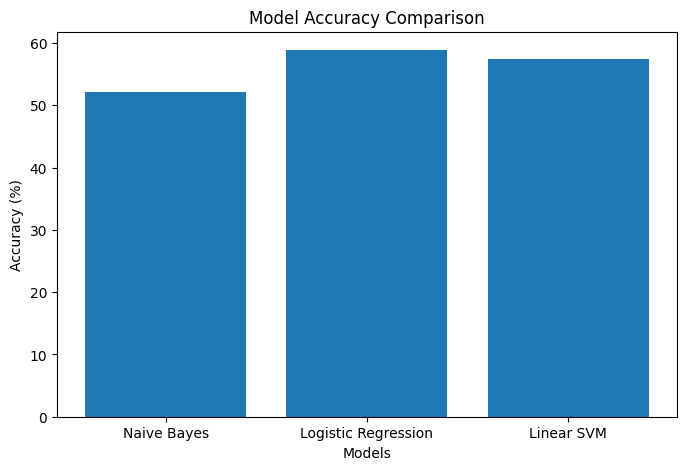

In [47]:
plt.figure(figsize=(8,5))

plt.bar(results["Model"], results["Accuracy"] * 100)

plt.title("Model Accuracy Comparison")

plt.xlabel("Models")

plt.ylabel("Accuracy (%)")

plt.show()

In [48]:
import joblib

import numpy as np

In [49]:
best_model = svm_model

In [50]:
cm = confusion_matrix(y_test, svm_predictions)

print(cm)

[[  444     4    22     8     1   116    18    98   345     6     7     1
      3    46     3     2     1     2     6     0    38    51    21     1
     55     0    15]
 [    4   240    26     1     0   122     2    29   102     1     1     0
      0     6     0     0     0     0     1     1     4    42     2     0
      4     1     1]
 [   46    42   162    11     0    94     3    98   151    12    15     1
      3    30     0     0     2     1     9     0    22    40     3     0
     17     1    12]
 [   28     0    17    76     1    96     0    57    80    22    11     0
      0    19     4     0     0     0     5     2    19    55     1     1
      3     1     0]
 [    3     0     1     0     0    15     1   158    56     2     0     0
      0     2     6     0     0     0     0     0     0    16     3     1
      0     0     0]
 [   79    29    33    20     2  4271    21   380  1815    40     2    10
      1   119    16     8     9     3    43    37    14   380     7    17
     62

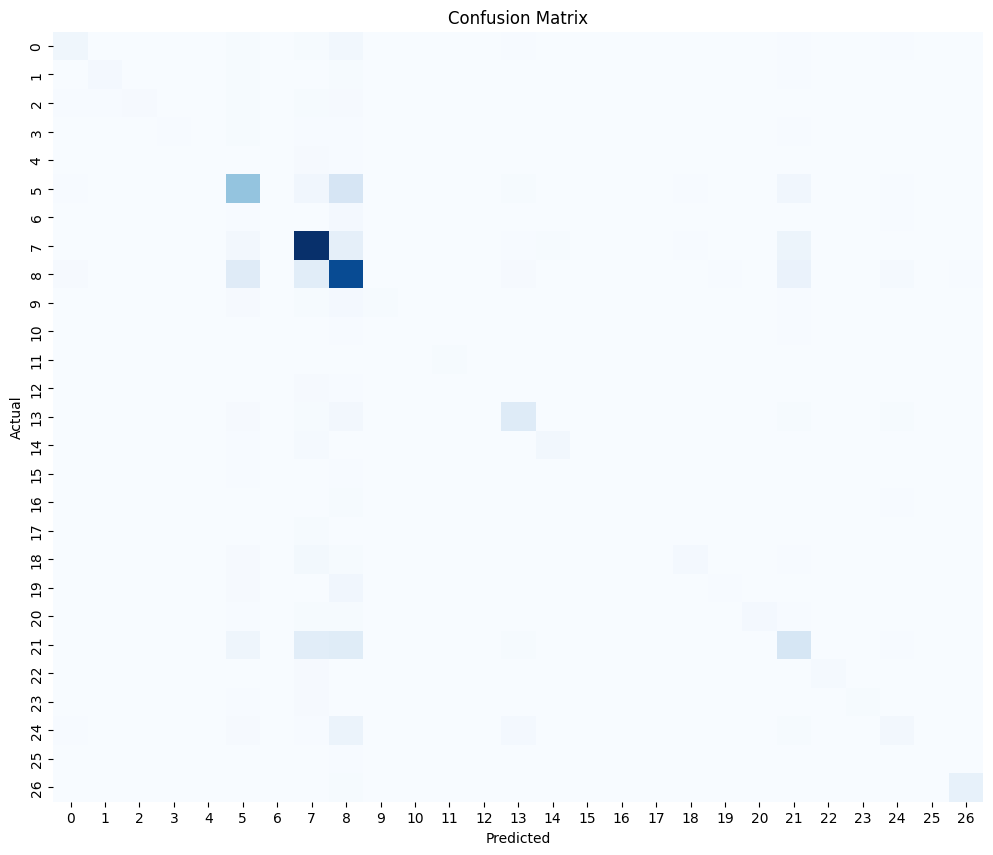

In [51]:
plt.figure(figsize=(12,10))

sns.heatmap(
    cm,
    cmap="Blues",
    cbar=False
)

plt.title("Confusion Matrix")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.show()

In [52]:
train_df["Genre"].value_counts().head(10)

,count
Genre,
drama,13613
documentary,13096
comedy,7447
short,5073
horror,2204
thriller,1591
action,1315
western,1032
reality-tv,884


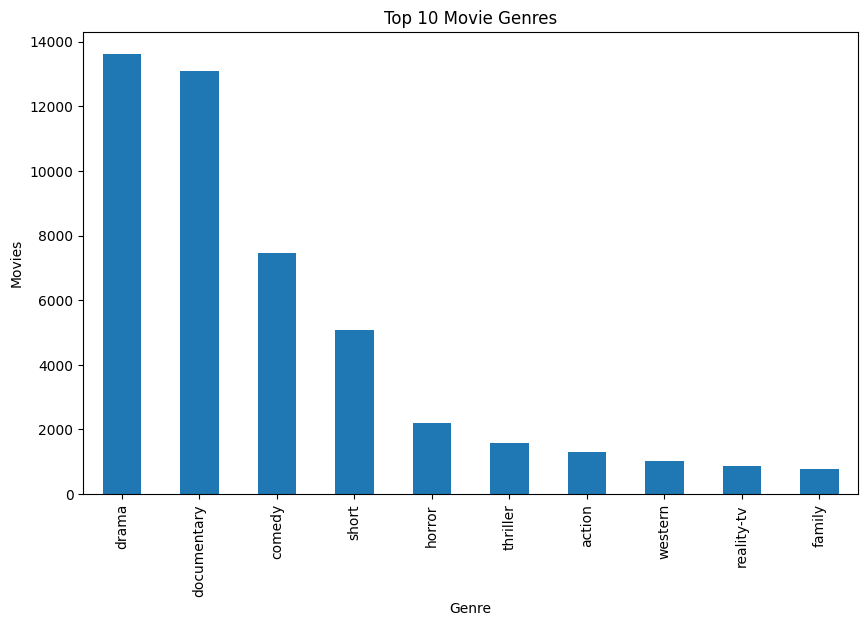

In [53]:
plt.figure(figsize=(10,6))

train_df["Genre"].value_counts().head(10).plot(kind="bar")

plt.title("Top 10 Movie Genres")

plt.xlabel("Genre")

plt.ylabel("Movies")

plt.show()

In [54]:
movie_plot = """
A young boy discovers magical powers and joins a school where he learns magic while fighting an evil wizard.
"""

movie_vector = tfidf.transform([movie_plot])

prediction = best_model.predict(movie_vector)

print("Predicted Genre:", prediction[0])

Predicted Genre: fantasy


In [55]:
movie_plot = """
A detective investigates a mysterious serial killer who leaves clues at every crime scene.
"""

movie_vector = tfidf.transform([movie_plot])

prediction = best_model.predict(movie_vector)

print("Predicted Genre:", prediction[0])

Predicted Genre: thriller


In [56]:
plot = input("Enter Movie Plot:\n")

vector = tfidf.transform([plot])

genre = best_model.predict(vector)

print("\nPredicted Genre:", genre[0])

Enter Movie Plot:
a pirate named jack sparrow do the adventures for various treasures

Predicted Genre: animation


In [57]:
joblib.dump(tfidf, "tfidf_vectorizer.pkl")

print("TF-IDF Saved")

TF-IDF Saved


In [58]:
joblib.dump(best_model, "movie_genre_model.pkl")

print("Model Saved")

Model Saved


In [59]:
loaded_model = joblib.load("movie_genre_model.pkl")

loaded_vectorizer = joblib.load("tfidf_vectorizer.pkl")

In [60]:
text = """
An alien spaceship lands on Earth and humanity prepares for an epic battle.
"""

vector = loaded_vectorizer.transform([text])

prediction = loaded_model.predict(vector)

print("Prediction:", prediction[0])

Prediction: sci-fi


In [61]:
results = results.sort_values(
    by="Accuracy",
    ascending=False
)

results

,Model,Accuracy
1,Logistic Regression,0.588764
2,Linear SVM,0.574114
0,Naive Bayes,0.521531


In [62]:
print("="*60)

print("Movie Genre Classification Project Completed Successfully!")

print("="*60)

print("Best Model :", results.iloc[0]["Model"])

print("Accuracy :", round(results.iloc[0]["Accuracy"]*100,2),"%")

Movie Genre Classification Project Completed Successfully!
Best Model : Logistic Regression
Accuracy : 58.88 %
